# CONSTELLATION: Compartment-Level Spatial LR Analysis

This notebook demonstrates CONSTELLATION analysis across **spatial compartments** rather than cell types. Compartments are user-defined regions (e.g., Tumor, Interface, Stroma) that partition the tissue based on spatial context.

**Dataset**: 10x Xenium CRC, 307,762 cells, 541 genes

## Prerequisites

**Users must provide a compartment label for each cell.** Compartments can be defined by:
- Distance from a boundary (e.g., tumor edge)
- Pathologist annotations
- Spatial clustering / domain segmentation
- Anatomical regions

> **Note**: In this dataset, compartment annotations were transferred from VisiumHD to Xenium cells using spatial nearest-neighbor matching. See `crc_preprocessing.ipynb` for details on the annotation transfer procedure.

## Key Concepts

- **Compartment-level analysis**: Test LR colocalization within each spatial compartment
- **User-defined regions**: You define the compartments; CONSTELLATION tests within them
- **Cross-boundary signaling**: Identify LR pairs enriched at tissue interfaces

---
## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.sparse import csc_matrix
import constellation as cst
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# USER INPUT: Data paths
# =============================================================================
# Cell metadata with compartment annotations
META_PATH = '/Users/mchen12/spatialLR/crc/xenium_final.parquet'

# Expression matrix (10x Xenium H5 format)
H5_PATH = '/Users/mchen12/spatialLR/crc_data/Xenium_P1CRC/cell_feature_matrix.h5'

In [2]:
# Load cell metadata
print('Loading cell metadata...')
meta_raw = pd.read_parquet(META_PATH)
print(f'  Total cells: {len(meta_raw):,}')

# =============================================================================
# USER INPUT: Specify the compartment column
# =============================================================================
# The compartment column should contain categorical labels for each cell.
# Examples: 'Tumor', 'Interface', 'Stroma' or 'Core', 'Margin', 'Normal'

COMPARTMENT_COL = 'compartment'  # <-- Change this to your column name

# Validate compartment column exists
if COMPARTMENT_COL not in meta_raw.columns:
    raise ValueError(f"Compartment column '{COMPARTMENT_COL}' not found in metadata. "
                     f"Available columns: {list(meta_raw.columns)}")

# Filter to cells with valid compartment annotations
meta = meta_raw[meta_raw[COMPARTMENT_COL].notna()].copy()
n_filtered = len(meta_raw) - len(meta)
if n_filtered > 0:
    print(f'  Filtered {n_filtered:,} cells with missing compartment')
print(f'  Cells with compartment: {len(meta):,}')

# Show compartment distribution
print(f'\nCompartment column: {COMPARTMENT_COL}')
print(f'Compartment distribution:')
for comp, n in meta[COMPARTMENT_COL].value_counts().items():
    print(f'  {comp}: {n:,} ({100*n/len(meta):.1f}%)')

Loading cell metadata...


  Total cells: 307,762
  Filtered 28,770 cells with missing compartment
  Cells with compartment: 278,992

Compartment column: compartment
Compartment distribution:
  Tissue: 184,078 (66.0%)
  Tumor: 74,858 (26.8%)
  50 micron: 20,056 (7.2%)


In [3]:
# Load expression matrix from H5 file
print('Loading expression matrix...')
with h5py.File(H5_PATH, 'r') as f:
    matrix = f['matrix']
    gene_names = [g.decode() for g in matrix['features']['name'][:]]
    barcodes = [b.decode() for b in matrix['barcodes'][:]]
    data = matrix['data'][:]
    indices_h5 = matrix['indices'][:]
    indptr = matrix['indptr'][:]
    shape = matrix['shape'][:]

expr_sparse_full = csc_matrix((data, indices_h5, indptr), shape=shape).T
print(f'  Full expression: {expr_sparse_full.shape[0]:,} cells x {expr_sparse_full.shape[1]} genes')

# Filter expression to cells with valid compartments
# Build index mapping: cell_id -> row index in expression matrix
barcode_to_idx = {b: i for i, b in enumerate(barcodes)}
valid_indices = [barcode_to_idx[cid] for cid in meta['cell_id'].values]
expr_sparse = expr_sparse_full[valid_indices, :]
print(f'  Filtered expression: {expr_sparse.shape[0]:,} cells x {expr_sparse.shape[1]} genes')

# Create gene lookup
gene_to_idx = {g: i for i, g in enumerate(gene_names)}

Loading expression matrix...


  Full expression: 307,762 cells x 541 genes


  Filtered expression: 278,992 cells x 541 genes


---
## 2. Spatial Compartments

In this dataset, compartments were pre-computed based on distance from the tumor boundary:
- **Tumor**: Cells inside the tumor region
- **50 micron** (Interface): Cells within 50 μm of the tumor boundary  
- **Tissue**: Normal tissue cells > 50 μm from tumor

Visualize the compartments to verify they make biological sense.

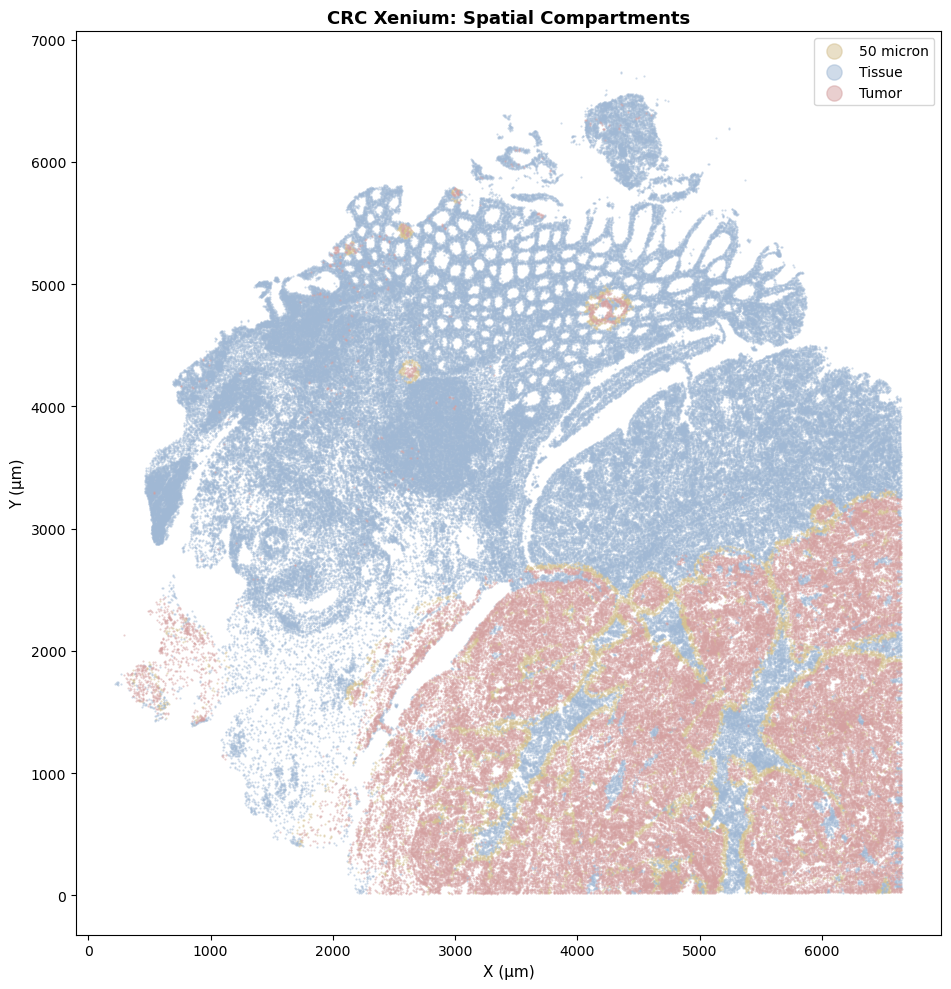

In [4]:
# Spatial coordinates and compartments
coords = meta[['x_centroid', 'y_centroid']].values
compartments = meta[COMPARTMENT_COL].values

# =============================================================================
# USER INPUT: Define compartment colors (optional)
# =============================================================================
COMP_COLORS = {
    'Tumor': '#d4a0a0',      # Muted red
    '50 micron': '#d4c090',  # Muted gold (interface)
    'Tissue': '#a0b8d4',     # Muted blue
}

# Use CONSTELLATION's compartment spatial plot
fig, ax = cst.plot_compartment_spatial(
    coords, compartments,
    compartment_colors=COMP_COLORS,
    point_size=0.3,
    figsize=(12, 10),
    title='CRC Xenium: Spatial Compartments'
)

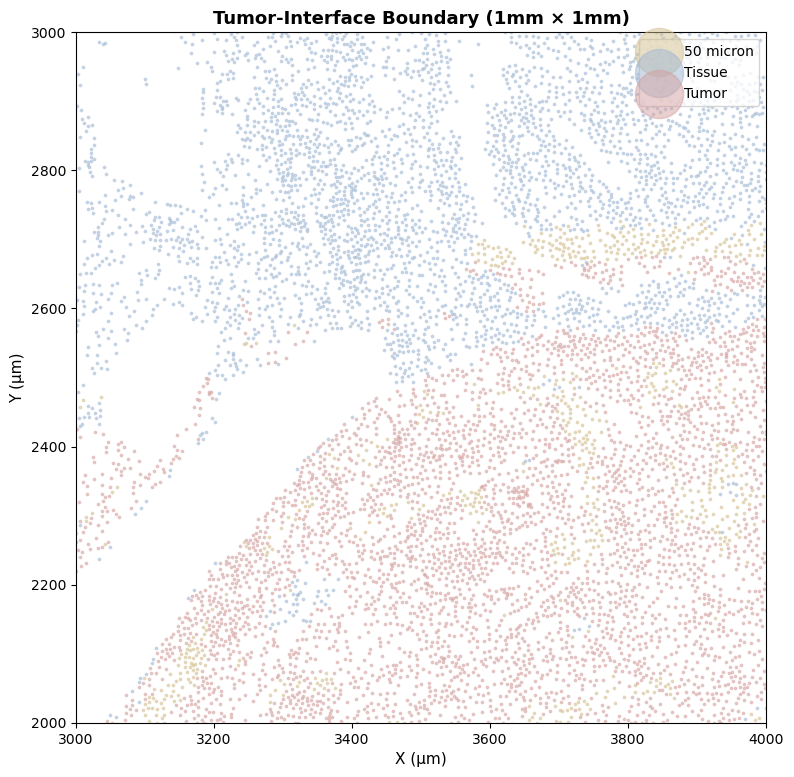

In [5]:
# Zoomed view of tumor-interface boundary
# This region selected for good representation of all three compartments
fig, ax = cst.plot_compartment_spatial(
    coords, compartments,
    compartment_colors=COMP_COLORS,
    point_size=3,
    figsize=(8, 8),
    xlim=(3000, 4000),
    ylim=(2000, 3000),
    title='Tumor-Interface Boundary (1mm × 1mm)'
)

---
## 3. LR Pairs & Expression Data

Load curated LR pairs for analysis. 

**Note**: We use a curated list rather than the full LIANA database because some database entries contain artifacts (e.g., ADRA2A receptor pairs from CellTalkDB/LRDB are likely false annotations).

In [6]:
# =============================================================================
# USER INPUT: LR pairs to test
# =============================================================================
# Option 1: Load from curated CSV file
LR_PAIRS_PATH = '/Users/mchen12/spatialLR/crc/lr_pairs_from_ln.csv'

# Option 2: Define manually
# lr_pairs = [('CXCL13', 'CXCR5'), ('CCL19', 'CCR7'), ...]

# Load LR pairs
lr_df = pd.read_csv(LR_PAIRS_PATH)
print(f'LR pairs from file: {len(lr_df)}')

# Filter to genes available in expression panel
gene_set = set(gene_names)
lr_pairs = []
lr_genes = set()
for _, row in lr_df.iterrows():
    lig, rec = row['ligand'], row['receptor']
    if lig in gene_set and rec in gene_set:
        lr_pairs.append((lig, rec))
        lr_genes.add(lig)
        lr_genes.add(rec)

print(f'Available in panel: {len(lr_pairs)}')
print(f'\nLR pairs to test:')
for lig, rec in lr_pairs:
    print(f'  {lig} -> {rec}')

LR pairs from file: 12
Available in panel: 12

LR pairs to test:
  CXCL13 -> ADRA2A
  CCL19 -> CCR7
  CXCL13 -> CXCR5
  CCL19 -> ADRA2A
  CXCL12 -> CXCR4
  CCL19 -> CXCR3
  CXCL12 -> CXCR3
  CXCL13 -> CXCR3
  CEACAM1 -> HAVCR2
  CXCL9 -> ADRA2A
  CXCL9 -> CXCR3
  TNFSF13B -> TNFRSF17


In [7]:
# Create expression dictionary for CONSTELLATION
print('Creating expression dictionary...')
expr_dict = {}
for gene in lr_genes:
    idx = gene_to_idx[gene]
    expr_dict[gene] = np.asarray(expr_sparse[:, idx].todense()).flatten()

print(f'  {len(expr_dict)} genes loaded')

Creating expression dictionary...


  13 genes loaded


In [8]:
# Scan compartments to see testable LR burden
report = cst.scan_compartments(
    expr_dict=expr_dict,
    compartments=compartments,
    lr_pairs=lr_pairs,
    min_expr_frac=0.01,
    min_cells=10,
    verbose=True
)

CONSTELLATION Compartment Scan
Total cells: 278,992
Compartments: 3
Input LR pairs: 12
Genes in expr_dict: 13

Expression threshold: 1.0%
Min ligand+ cells: 10

Compartment               Cells      Pct    Lig    Rec  Testable LR
----------------------------------------------------------------------
50 micron                20,056     7.2%      5      6            8
Tissue                  184,078    66.0%      6      7           12
Tumor                    74,858    26.8%      5      6            8
----------------------------------------------------------------------
TOTAL                   278,992   100.0%                         28


---
## 4. CONSTELLATION Compartment Analysis

Run compartment-level LR analysis using CONSTELLATION's `run_compartment_analysis()` function.

In [9]:
# Run CONSTELLATION compartment analysis
results = cst.run_compartment_analysis(
    expr_dict=expr_dict,
    compartments=compartments,
    coords=coords,
    lr_pairs=lr_pairs,
    k=10,
    min_cells=10,
    verbose=True
)

CONSTELLATION Compartment Analysis
Cells: 278,992
Compartments: ['50 micron', 'Tissue', 'Tumor']
LR pairs: 12

Building spatial graph (k=10)...



Testing 12 LR pairs x 3 compartments...


LR pairs:   0%|          | 0/12 [00:00<?, ?it/s]

LR pairs:  25%|██▌       | 3/12 [00:00<00:00, 22.24it/s]

LR pairs:  50%|█████     | 6/12 [00:00<00:00, 20.02it/s]

LR pairs:  75%|███████▌  | 9/12 [00:00<00:00, 12.16it/s]

LR pairs: 100%|██████████| 12/12 [00:00<00:00, 15.45it/s]

LR pairs: 100%|██████████| 12/12 [00:00<00:00, 15.55it/s]


RESULTS SUMMARY
Total tests: 36
Significant: 7 (p_adj < 0.05, z > 0)

By compartment:
  50 micron: 1
  Tissue: 4
  Tumor: 2


In [10]:
# Show significant results
sig_df = results[results['significant']].sort_values('z_score', ascending=False)
print(f'Significant interactions: {len(sig_df)}')
print('\n' + sig_df[['lr_pair', 'compartment', 'n_l_pos', 'fold_enrichment', 'z_score', 'p_adj']].to_string(index=False))

Significant interactions: 7

          lr_pair compartment  n_l_pos  fold_enrichment    z_score        p_adj
     CXCL13-CXCR5      Tissue    10840         3.153844 106.605007 0.000000e+00
       CCL19-CCR7      Tissue     4652         1.925585  43.256844 0.000000e+00
     CXCL13-CXCR3       Tumor     1294         1.449225   6.670230 1.532428e-10
      CXCL9-CXCR3       Tumor     1985         1.318475   5.856867 2.122564e-08
    CXCL13-ADRA2A   50 micron      347         1.162345   4.327668 5.425079e-05
TNFSF13B-TNFRSF17      Tissue     6037         1.123681   4.209254 7.686464e-05
     CXCL13-CXCR3      Tissue    10840         1.069672   2.994208 7.075493e-03


---
## 5. Visualization

### Detection Heatmap

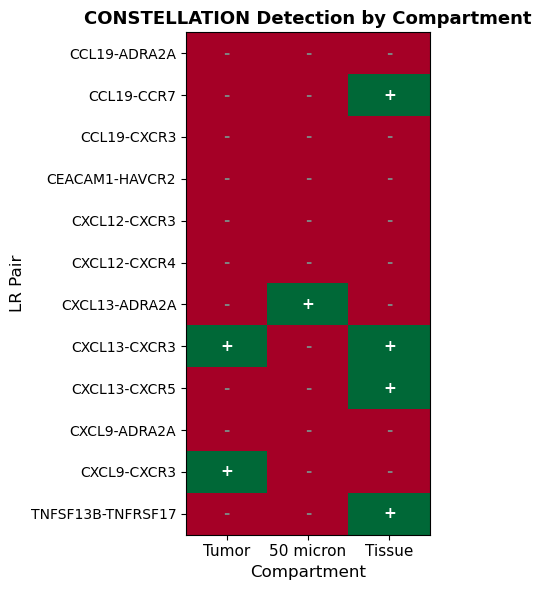

In [11]:
# Detection heatmap using CONSTELLATION
fig, ax = cst.plot_compartment_heatmap(
    results,
    value_col='significant',
    compartment_order=['Tumor', '50 micron', 'Tissue'],
    title='CONSTELLATION Detection by Compartment'
)

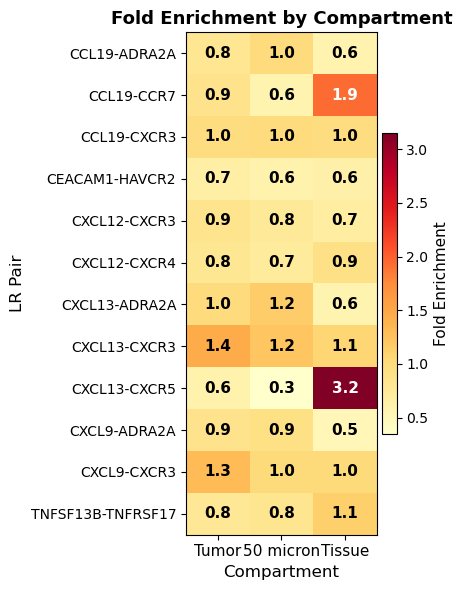

In [12]:
# Fold enrichment heatmap
fig, ax = cst.plot_compartment_heatmap(
    results,
    value_col='fold_enrichment',
    compartment_order=['Tumor', '50 micron', 'Tissue'],
    cmap='YlOrRd',
    title='Fold Enrichment by Compartment'
)

---
## 6. Distance Profile Analysis

Examine how LR colocalization varies with **signed distance from the tumor-tissue interface**.

The interface serves as the origin (distance = 0):
- **Negative distances**: Inside the tumor
- **Positive distances**: Outside the tumor (in normal tissue)

This analysis reveals whether LR colocalization peaks at the interface or within specific compartments.

In [13]:
# Compute signed distance to tumor-tissue interface
# The interface is defined by cells near the boundary between Tumor and non-Tumor regions
from scipy.spatial import cKDTree

print('Computing signed distance to interface...')

# Identify tumor and non-tumor cells
tumor_mask = compartments == 'Tumor'
tumor_coords = coords[tumor_mask]
tissue_coords = coords[~tumor_mask]

print(f'  Tumor cells: {tumor_mask.sum():,}')
print(f'  Non-tumor cells: {(~tumor_mask).sum():,}')

# Build KD-trees for each compartment
tumor_tree = cKDTree(tumor_coords)
tissue_tree = cKDTree(tissue_coords)

# Find boundary cells (cells within 30μm of the opposite compartment)
BOUNDARY_THRESHOLD = 30  # μm

# Tumor cells near tissue
tumor_to_tissue_dist, _ = tissue_tree.query(tumor_coords, k=1)
boundary_tumor = tumor_coords[tumor_to_tissue_dist < BOUNDARY_THRESHOLD]
print(f'  Tumor boundary cells: {len(boundary_tumor):,}')

# Tissue cells near tumor
tissue_to_tumor_dist, _ = tumor_tree.query(tissue_coords, k=1)
boundary_tissue = tissue_coords[tissue_to_tumor_dist < BOUNDARY_THRESHOLD]
print(f'  Tissue boundary cells: {len(boundary_tissue):,}')

# Combine boundary cells to define the interface
boundary_coords = np.vstack([boundary_tumor, boundary_tissue])
boundary_tree = cKDTree(boundary_coords)
print(f'  Total interface cells: {len(boundary_coords):,}')

# Compute distance to interface for all cells
dist_to_interface, _ = boundary_tree.query(coords, k=1)

# Signed distance: negative inside tumor, positive in tissue
signed_distance = np.where(tumor_mask, -dist_to_interface, dist_to_interface)

print(f'\nSigned distance range:')
print(f'  Tumor (negative): {signed_distance[tumor_mask].min():.1f} to {signed_distance[tumor_mask].max():.1f} μm')
print(f'  Tissue (positive): {signed_distance[~tumor_mask].min():.1f} to {signed_distance[~tumor_mask].max():.1f} μm')

Computing signed distance to interface...
  Tumor cells: 74,858
  Non-tumor cells: 204,134
  Tumor boundary cells: 48,526


  Tissue boundary cells: 28,352
  Total interface cells: 76,878



Signed distance range:
  Tumor (negative): -281.8 to -0.0 μm
  Tissue (positive): 0.0 to 1444.3 μm


In [14]:
# Build spatial graph for distance profile computation
indices, neighbor_distances = cst.build_spatial_graph_from_coords(coords, k=10)

# Compute distance profiles for key LR pairs
# Focus on pairs that showed compartment-specific enrichment
LR_PAIRS_TO_PROFILE = [
    ('CXCL13', 'CXCR5'),  # Tissue enriched - chemokine
    ('CXCL9', 'CXCR3'),   # Tumor enriched - IFN-induced
    ('CCL19', 'CCR7'),    # Tissue enriched - T cell homing
]

print('Computing distance profiles...\n')
profiles = {}
for lig, rec in LR_PAIRS_TO_PROFILE:
    if lig in expr_dict and rec in expr_dict:
        profile = cst.compute_distance_profile(
            expr_dict=expr_dict,
            ligand=lig,
            receptor=rec,
            distance_values=signed_distance,
            indices=indices,
            bin_width=20,  # 20 μm bins
            min_cells=100
        )
        profiles[(lig, rec)] = profile
        print(f'{lig}-{rec}: {len(profile)} bins')
    else:
        print(f'{lig}-{rec}: genes not available')

Spatial graph: 278,992 cells, k=10 neighbors
  Median NN1 distance: 6.31
Computing distance profiles...

CXCL13-CXCR5: 5 bins


CXCL9-CXCR3: 5 bins
CCL19-CCR7: 5 bins


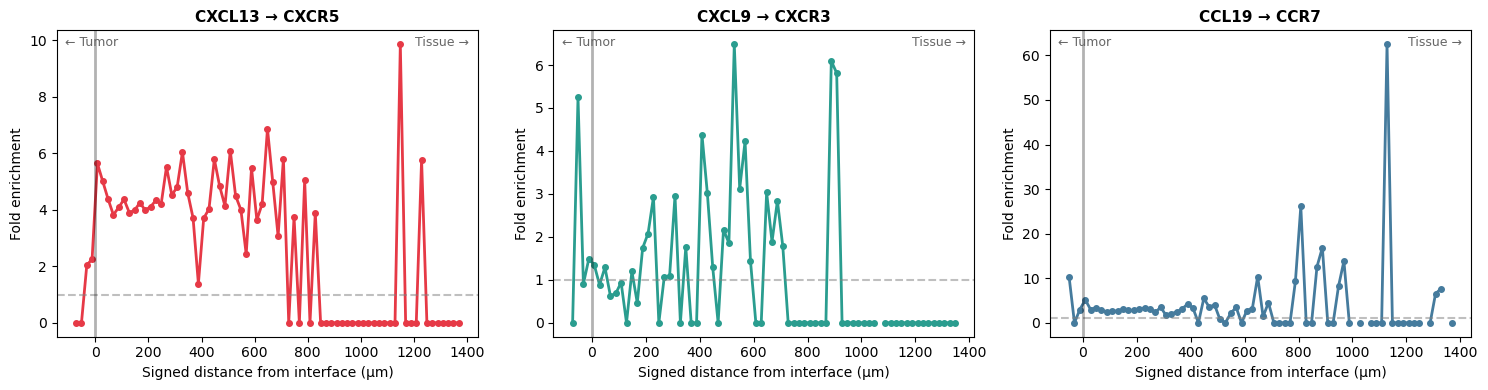


Interpretation:
- CXCL13-CXCR5: Enriched in tissue (positive distance), chemokine signaling
- CXCL9-CXCR3: Peaks in tumor (negative distance), IFN-induced immune response
- CCL19-CCR7: Tissue enriched, T cell/DC homing to lymphoid structures


In [15]:
# Plot distance profiles for selected LR pairs
# Create a combined visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Color scheme for LR pairs
colors = ['#e63946', '#2a9d8f', '#457b9d']

for i, ((lig, rec), profile) in enumerate(profiles.items()):
    ax = axes[i]
    
    bin_centers = profile['bin_centers']
    coexpr_fold = profile['coexpr_fold']
    
    # Plot
    ax.plot(bin_centers, coexpr_fold, 'o-', color=colors[i],
            linewidth=2, markersize=4)
    
    # Reference line (expected = 1)
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    
    # Interface boundary marker
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.3, linewidth=2)
    
    ax.set_xlabel('Signed distance from interface (μm)', fontsize=10)
    ax.set_ylabel('Fold enrichment', fontsize=10)
    ax.set_title(f'{lig} → {rec}', fontsize=11, fontweight='bold')
    
    # Add compartment labels
    ax.text(0.02, 0.98, '← Tumor', transform=ax.transAxes, 
            fontsize=9, va='top', ha='left', color='#666')
    ax.text(0.98, 0.98, 'Tissue →', transform=ax.transAxes,
            fontsize=9, va='top', ha='right', color='#666')

plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('- CXCL13-CXCR5: Enriched in tissue (positive distance), chemokine signaling')
print('- CXCL9-CXCR3: Peaks in tumor (negative distance), IFN-induced immune response')
print('- CCL19-CCR7: Tissue enriched, T cell/DC homing to lymphoid structures')

---
## 7. Summary

This notebook demonstrated CONSTELLATION's compartment-level analysis:

### Functions Used

**I/O & Data Loading**
- `cst.load_lr_resource('consensus')` - Load LR pairs from LIANA database
- `cst.filter_lr_pairs_by_genes()` - Filter to genes in panel
- `cst.build_spatial_graph_from_coords()` - Build k-NN graph from coordinates

**Compartment Analysis**
- `cst.scan_compartments()` - Report testable LR burden per compartment
- `cst.run_compartment_analysis()` - Main function for compartment-level LR testing
- `cst.compute_distance_profile()` - LR colocalization vs distance from boundary

**Visualization**
- `cst.plot_compartment_spatial()` - Spatial map colored by compartment
- `cst.plot_compartment_heatmap()` - Detection/enrichment heatmap across compartments
- `cst.plot_distance_profile()` - Visualize distance profiles

### Key Findings

- CONSTELLATION identifies compartment-specific LR interactions
- The tumor-stroma interface shows distinct signaling patterns
- Distance profiles reveal how signaling changes across tissue boundaries

In [16]:
# Summary statistics
print('Results by compartment:')
print(results.groupby('compartment')['significant'].agg(['sum', 'count']))

# Print results summary using CONSTELLATION
cst.print_results_summary(results)

Results by compartment:
             sum  count
compartment            
50 micron      1     12
Tissue         4     12
Tumor          2     12

Total tests: 36
Significant at p<0.05: 8 (22.2%)
Significant at FDR<0.05: 7 (19.4%)
